# Raw Delta / Conductance Values

Показываем сырые значения `delta_chw = activation(patched) - activation(clean)` и кондактанса `segmentig_chw` на `model.22`.

Здесь нет разреза по каналам и нет разреза по success/fail. Графики показывают просто raw values: гистограммы, ECDF, scatter и несколько индивидуальных raw-карт с colorbar в исходной шкале.

## Setup и общий attack cache

In [1]:
from pathlib import Path
import os
import sys
import tempfile

_plot_cache = Path(tempfile.gettempdir()) / "patch_success_plot_cache"
_mpl_cache = _plot_cache / "matplotlib"
_xdg_cache = _plot_cache / "xdg"
_mpl_cache.mkdir(parents=True, exist_ok=True)
_xdg_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_cache))
os.environ.setdefault("XDG_CACHE_HOME", str(_xdg_cache))

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

from patch_success_analysis.notebook_setup import ensure_new_experiments_cwd, make_coco_people_patch_success_experiment
from patch_success_analysis.patching import build_clean_and_patched_letterboxed
from patch_success_analysis import raw_maps

cwd = ensure_new_experiments_cwd()
layer_name = "model.22"
attack_config, config, exp = make_coco_people_patch_success_experiment(target_layer=layer_name)
cache = exp.build_or_load_cache(force=False)
print(f"cwd={cwd}")
print(f"device={attack_config.device}")
print(f"target_layer={config.target_layer}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(cache.to_summary())

cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
device=mps
target_layer=model.22
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
{'cache_key': 'e91cdfc4a2c4e20d', 'config': {'dataset_path': ['../datasets/COCO_people'], 'patch_path': '../data/patch.png', 'model_path': 'yolo11s.pt', 'output_dir': 'new_experiments/outputs/patch_success_analysis', 'imgsz': 640, 'device': 'mps', 'target_class_name': 'person', 'conf': 0.01, 'success_thresh': 0.3, 'seed': 17, 'pool_size': 7200, 'n_success': 3000, 'n_fail': 3000, 'apply_patch_after_letterbox': True, 'patch_xy': (0, 0)}, 'balanced_total': 5650, 'balanced_success': 3000, 'balanced_fail': 2650, 'pool_total': 7200, 'pool_success': 4550, 'pool_fail': 2650, 'pool_failed_images': 0, 'failed_paths': []}


## Загрузка существующих layer-map cache

In [2]:
n_examples = 24

selected_examples = cache.examples[:n_examples]
raw_df, skipped = raw_maps.load_cached_raw_map_rows(exp, selected_examples, layer_name=layer_name)

print(f"selected={len(selected_examples)}, loaded={len(raw_df)}, skipped={len(skipped)}")
if skipped:
    display(pd.DataFrame(skipped).head(20))

summary_cols = [
    "path",
    "drop",
    "conf_clean",
    "conf_patch",
    "delta_min",
    "delta_p01",
    "delta_p50",
    "delta_p99",
    "delta_max",
    "delta_mean_abs",
    "conductance_min",
    "conductance_p01",
    "conductance_p50",
    "conductance_p99",
    "conductance_max",
    "conductance_mean_abs",
]
display(raw_df[summary_cols])

selected=24, loaded=24, skipped=0


,path,drop,conf_clean,conf_patch,delta_min,delta_p01,delta_p50,delta_p99,delta_max,delta_mean_abs,conductance_min,conductance_p01,conductance_p50,conductance_p99,conductance_max,conductance_mean_abs
0,../datasets/COCO_people/06356_train2017_image4...,0.402123,0.933572,0.531450,-8.195312,-1.091797,-5.592346e-03,1.336914,8.078125,0.224153,-1.618164,-0.010880,0.0,0.015572,1.199219,0.001303
1,../datasets/COCO_people/00972_train2017_image3...,0.636096,0.876672,0.240576,-8.781250,-1.219736,-1.913452e-02,1.352539,7.652344,0.246661,-11.125000,-0.015808,0.0,0.022964,38.531250,0.002827
2,../datasets/COCO_people/01552_train2017_image1...,0.876263,0.876263,0.000000,-9.718750,-1.986338,1.252174e-03,1.548828,7.453125,0.296279,-1.374023,-0.013100,0.0,0.023682,6.718750,0.002129
3,../datasets/COCO_people/02665_train2017_image8...,0.369444,0.926853,0.557409,-9.734375,-1.138682,-1.550293e-02,1.371094,8.296875,0.227553,-7.941406,-0.022232,0.0,0.032806,9.093750,0.003011
4,../datasets/COCO_people/04480_train2017_image1...,0.004722,0.900169,0.895448,-4.675781,-0.947266,-7.772446e-03,1.056650,6.992188,0.178304,-6.167969,-0.038148,0.0,0.054657,8.929688,0.005151
5,../datasets/COCO_people/02406_train2017_image2...,0.937165,0.937165,0.000000,-5.882812,-1.156250,-2.510071e-02,1.309570,7.718750,0.235727,-3.082031,-0.011078,0.0,0.017868,3.082031,0.001762
6,../datasets/COCO_people/03399_val2017_image513...,0.436943,0.906655,0.469712,-11.429688,-1.416016,-8.354187e-03,1.297861,7.734375,0.237129,-78.062500,-0.025208,0.0,0.028244,52.562500,0.005638
7,../datasets/COCO_people/05504_train2017_image2...,0.907985,0.907985,0.000000,-6.992188,-1.185557,-1.249695e-02,1.321289,7.488281,0.226527,-10.593750,-0.035217,0.0,0.051727,6.070312,0.004528
8,../datasets/COCO_people/05821_train2017_image4...,0.779818,0.887421,0.107604,-15.031250,-1.668955,-3.199577e-04,1.450195,7.375000,0.258277,-1.561523,-0.018631,0.0,0.036896,3.390625,0.002776
9,../datasets/COCO_people/00841_train2017_image3...,0.272878,0.900544,0.627666,-8.820312,-1.929697,-1.111031e-03,1.554697,7.847656,0.262534,-1.110352,-0.014404,0.0,0.023773,2.908203,0.002015


## Несколько индивидуальных raw-карт

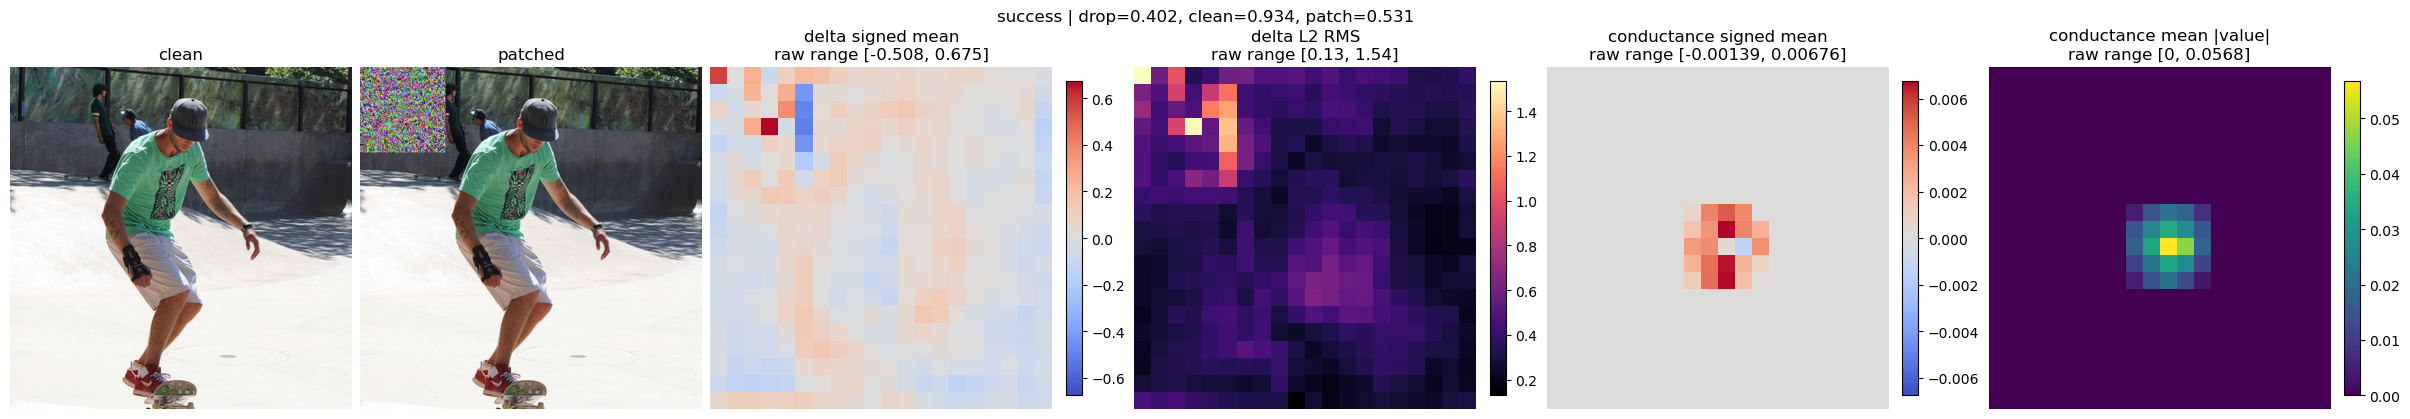

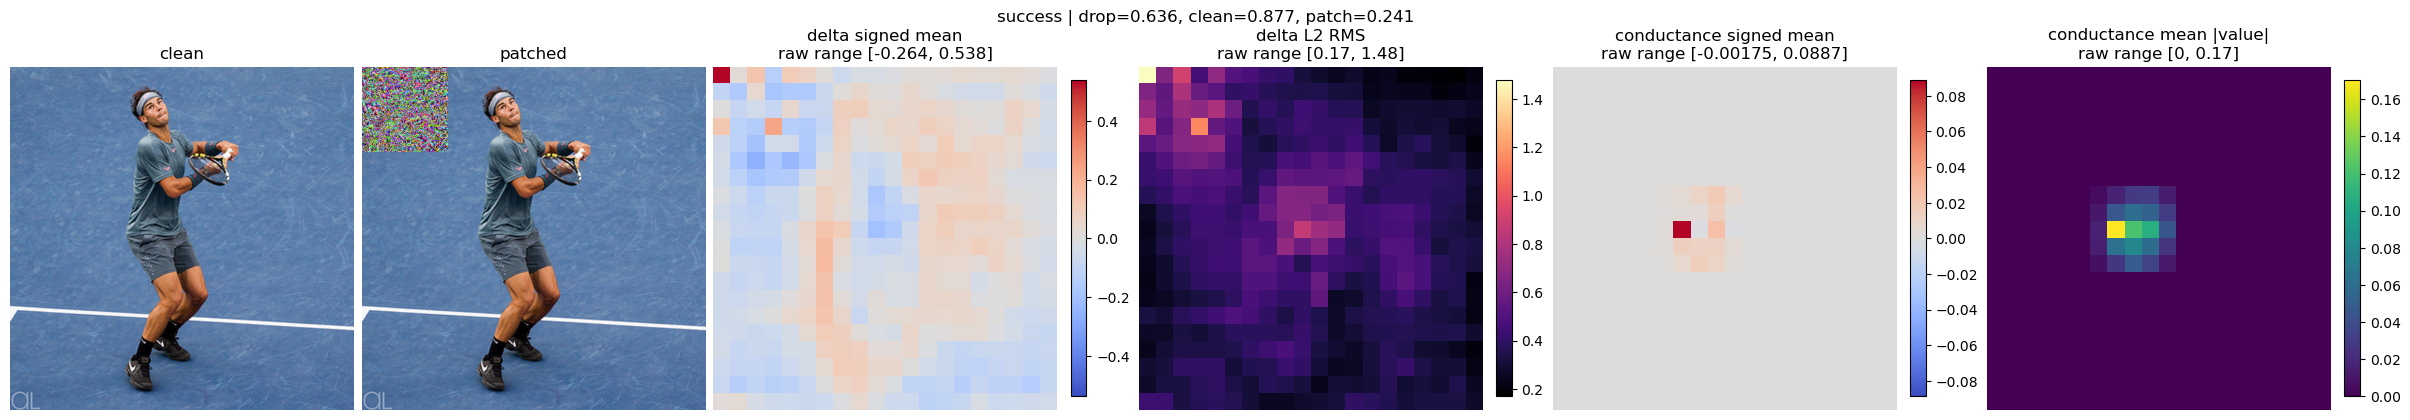

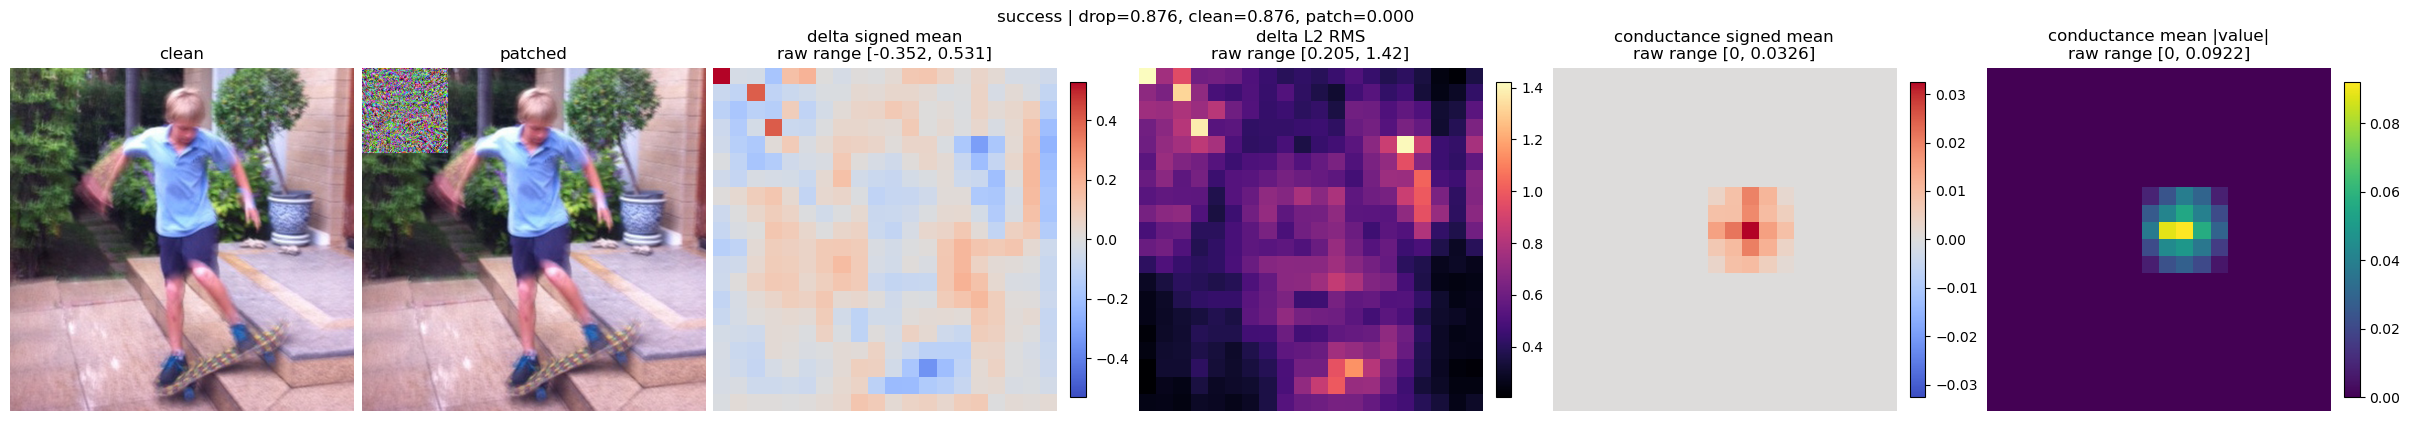

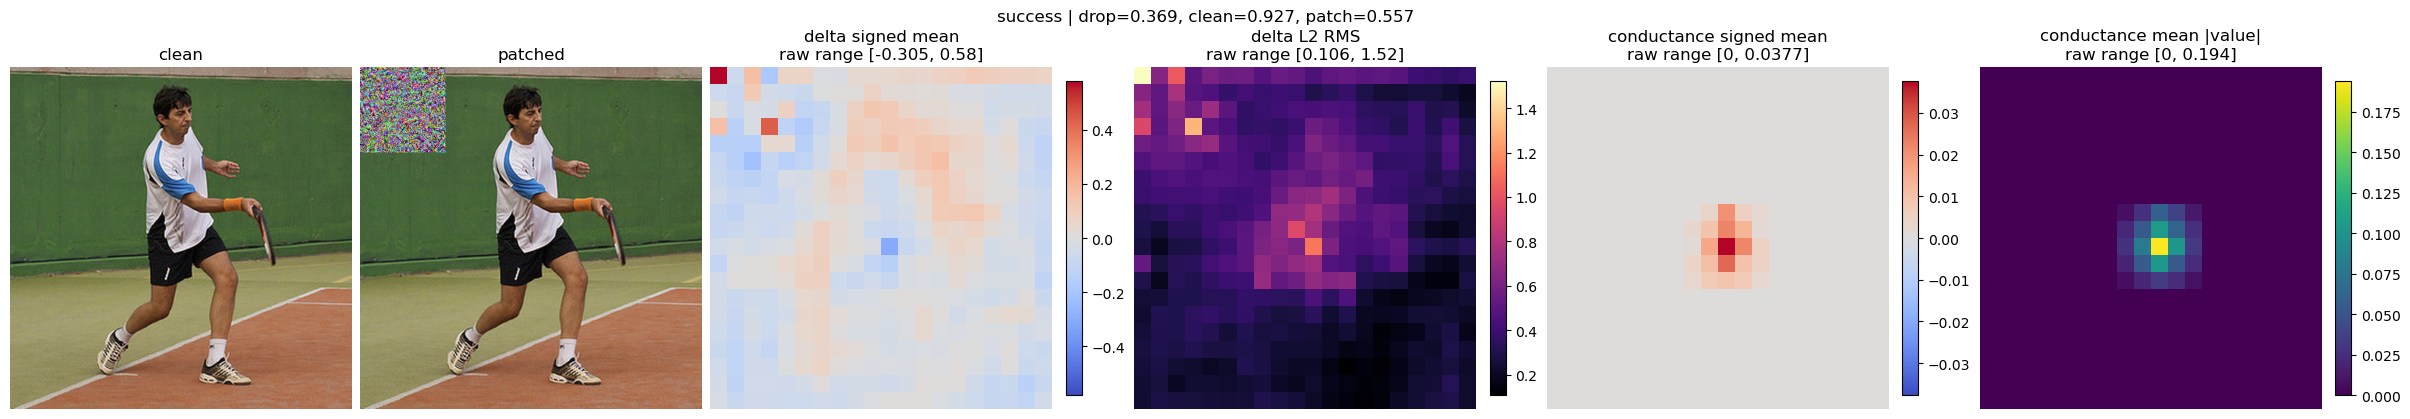

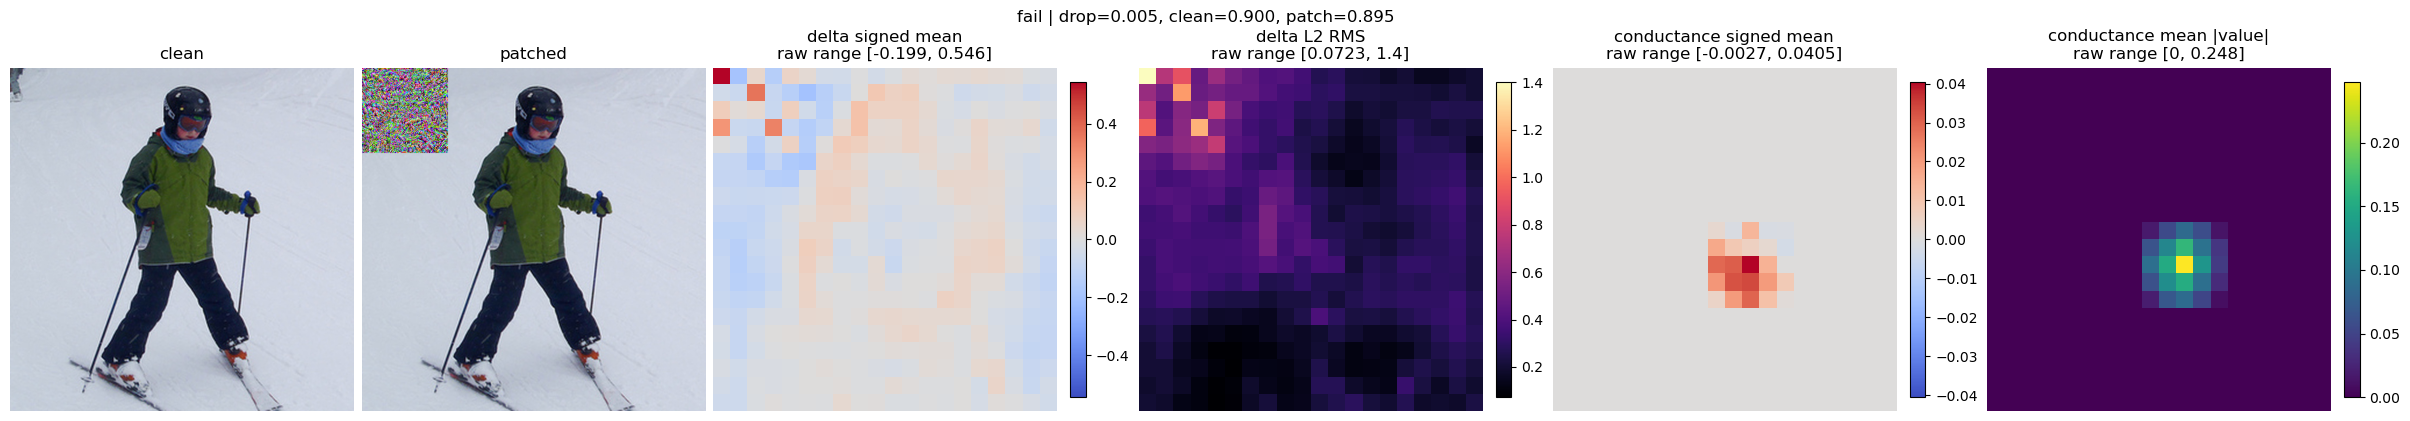

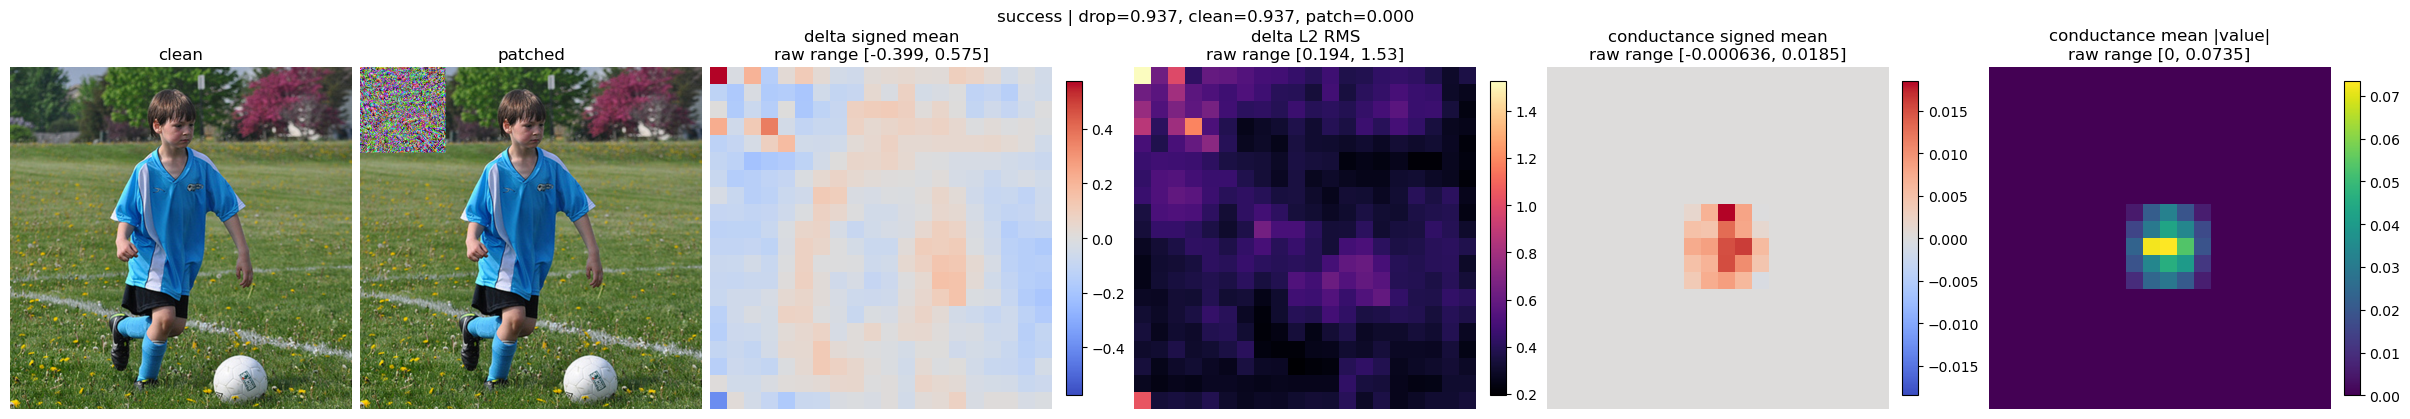

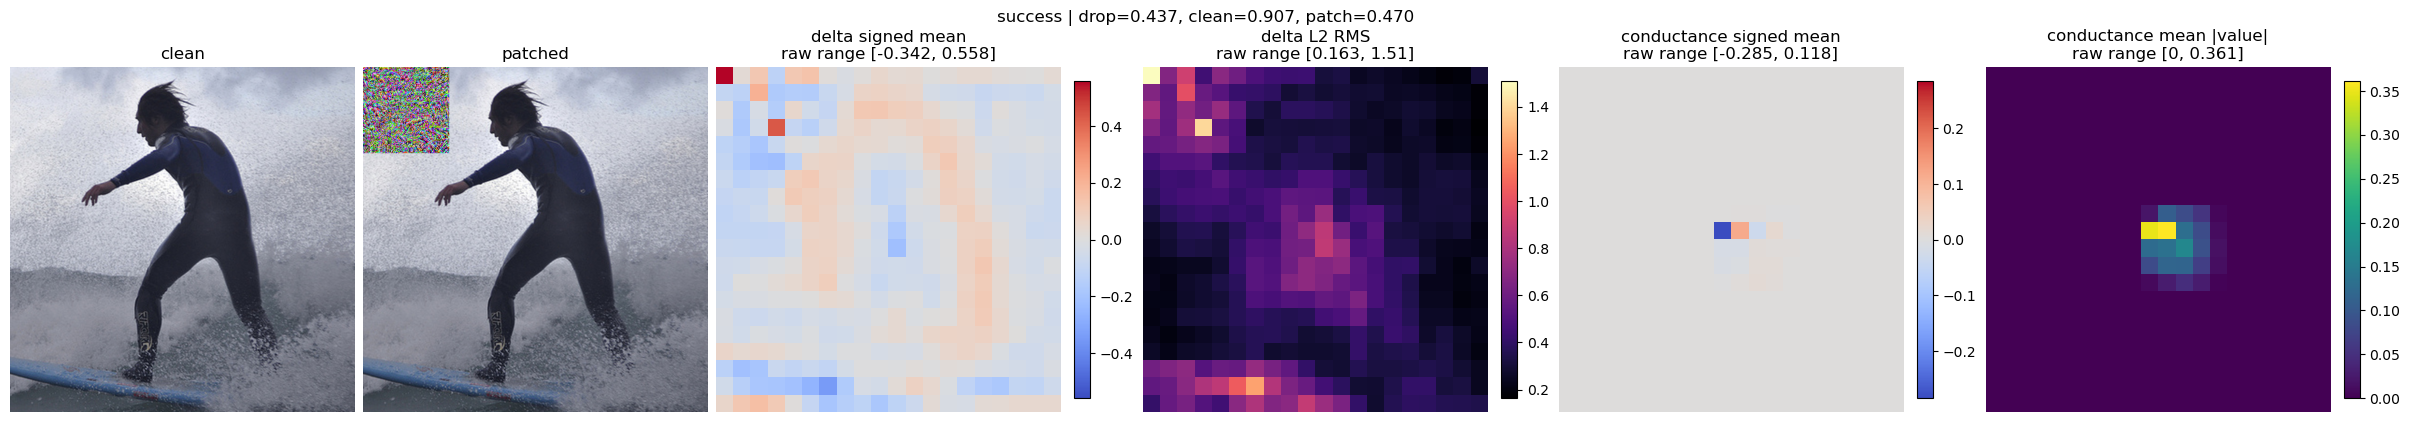

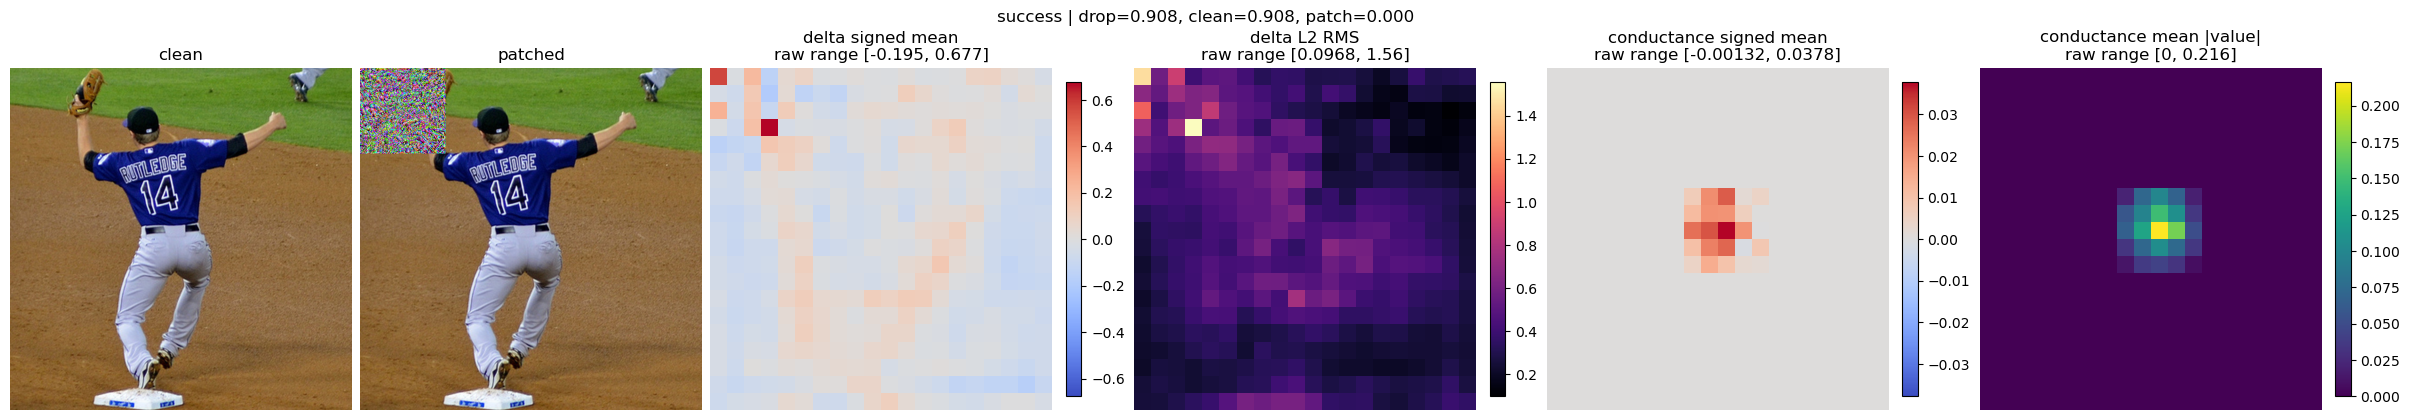

In [3]:
patch_pil = Image.open(attack_config.patch_path).convert("RGB")

def clean_patched_for_path(path):
    with Image.open(path) as image:
        base = image.convert("RGB")
    clean_lb, patched_lb, _patch_bbox = build_clean_and_patched_letterboxed(base, patch_pil, attack_config)
    return clean_lb, patched_lb

individual_n = 8
for _, row in raw_df.head(individual_n).iterrows():
    clean_lb, patched_lb = clean_patched_for_path(row["path"])
    fig = raw_maps.plot_raw_example_maps(row, clean_img=clean_lb, patched_img=patched_lb)
    plt.show()

## Top conductance vs top delta внутри одной картинки


,subset,k,overlap,overlap_frac,mean_abs_delta_on_top_conductance,mean_abs_conductance_on_top_delta
0,top200,200,2,0.010000,0.463817,0.005153
1,top1pct,2048,83,0.040527,0.326912,0.006131
2,top10pct,20480,2197,0.107275,0.219973,0.002703


top200


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top200 by |conductance|,1,52211,130,10,11,0.750977,0.750977,-1.618164,1.618164
1,top200 by |conductance|,2,85411,213,10,11,0.957031,0.957031,1.199219,1.199219
2,top200 by |conductance|,3,52212,130,10,12,0.560059,0.560059,1.106445,1.106445
3,top200 by |conductance|,4,32570,81,8,10,-0.091736,0.091736,-1.091797,1.091797
4,top200 by |conductance|,5,85391,213,9,11,0.566895,0.566895,1.009766,1.009766
...,...,...,...,...,...,...,...,...,...,...
195,top200 by |conductance|,196,160591,401,9,11,0.262939,0.262939,-0.189819,0.189819
196,top200 by |conductance|,197,59009,147,10,9,-0.402100,0.402100,-0.189087,0.189087
197,top200 by |conductance|,198,95811,239,10,11,-0.103943,0.103943,-0.188843,0.188843
198,top200 by |conductance|,199,85430,213,11,10,1.117188,1.117188,0.186523,0.186523


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top200 by |delta|,1,16065,40,3,5,-8.195312,8.195312,0.0,0.0
1,top200 by |delta|,2,202444,506,2,4,8.078125,8.078125,0.0,0.0
2,top200 by |delta|,3,67200,168,0,0,7.773438,7.773438,0.0,0.0
3,top200 by |delta|,4,16000,40,0,0,7.609375,7.609375,0.0,0.0
4,top200 by |delta|,5,71644,179,2,4,7.324219,7.324219,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
195,top200 by |delta|,196,123725,309,6,5,-3.839844,3.839844,0.0,0.0
196,top200 by |delta|,197,53263,133,3,3,3.824219,3.824219,0.0,0.0
197,top200 by |delta|,198,31325,78,6,5,-3.822266,3.822266,0.0,0.0
198,top200 by |delta|,199,199786,499,9,6,3.798828,3.798828,0.0,0.0


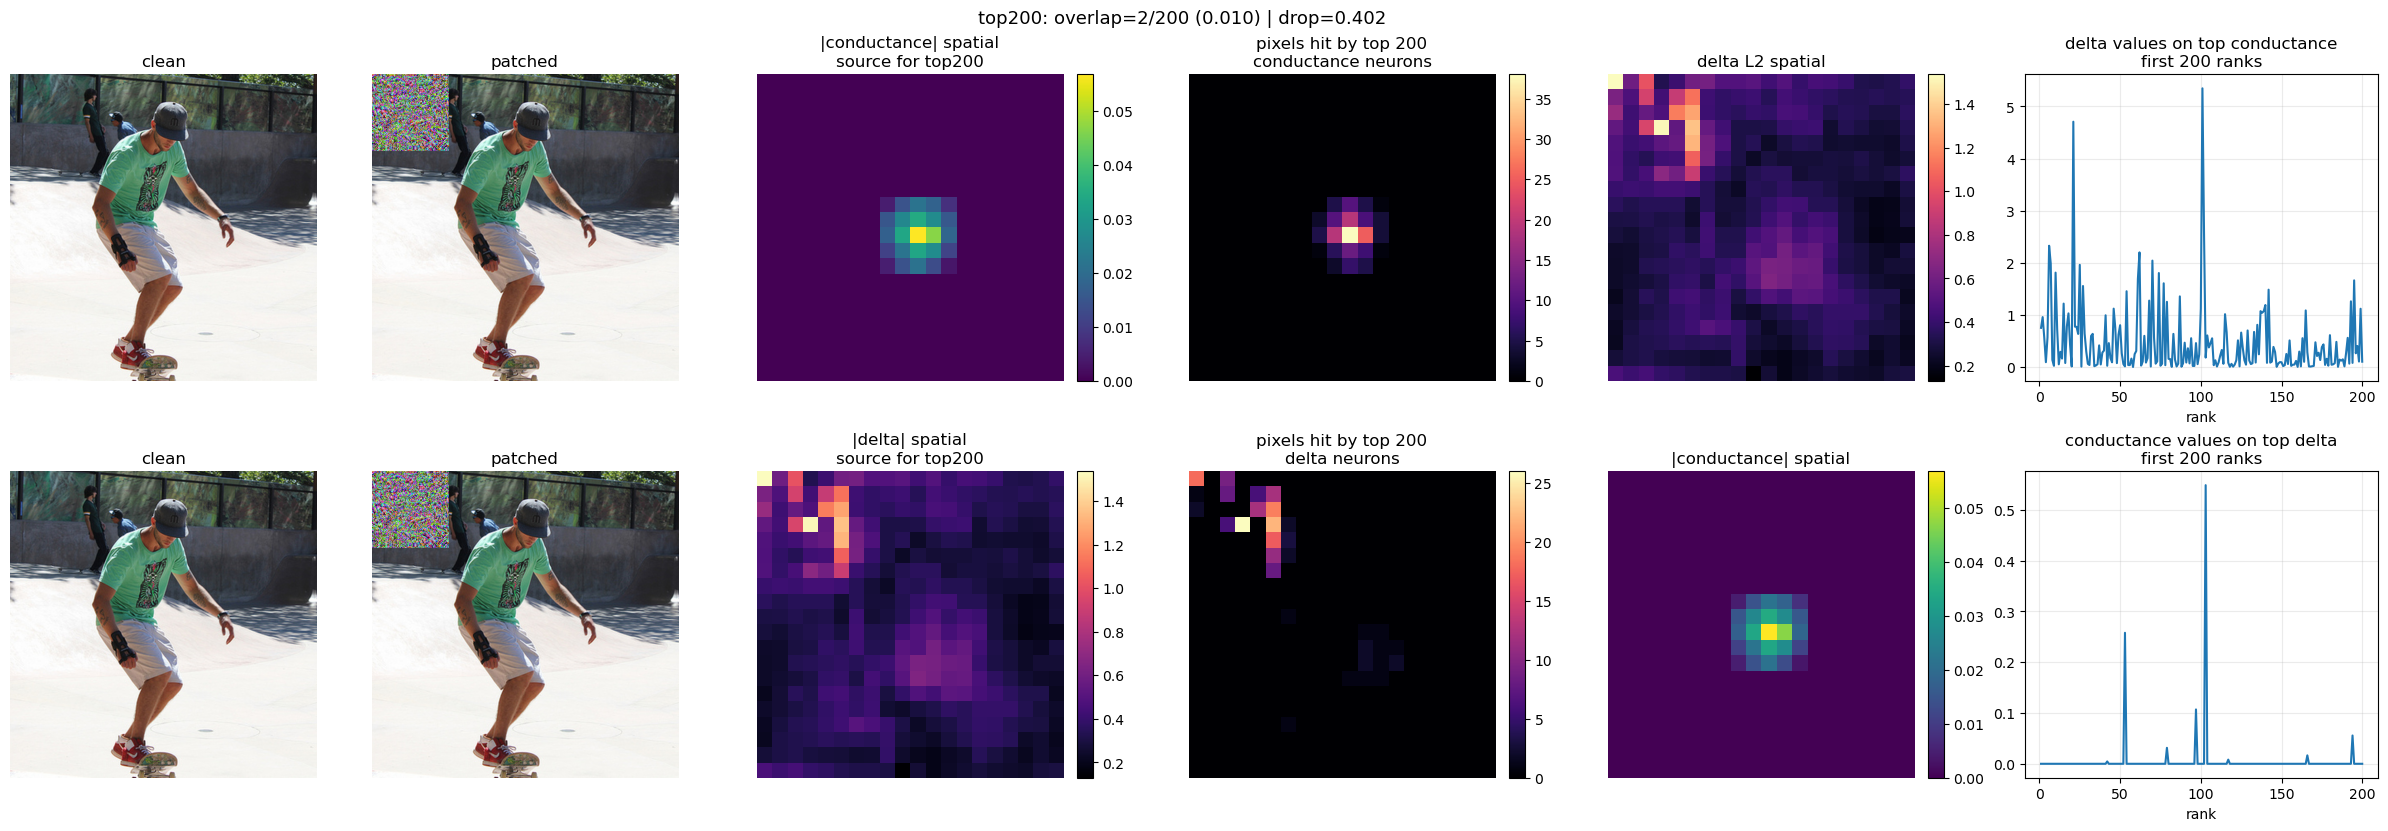

top1pct


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top1pct by |conductance|,1,52211,130,10,11,0.750977,0.750977,-1.618164,1.618164
1,top1pct by |conductance|,2,85411,213,10,11,0.957031,0.957031,1.199219,1.199219
2,top1pct by |conductance|,3,52212,130,10,12,0.560059,0.560059,1.106445,1.106445
3,top1pct by |conductance|,4,32570,81,8,10,-0.091736,0.091736,-1.091797,1.091797
4,top1pct by |conductance|,5,85391,213,9,11,0.566895,0.566895,1.009766,1.009766
...,...,...,...,...,...,...,...,...,...,...
195,top1pct by |conductance|,196,31811,79,10,11,-1.662109,1.662109,0.189819,0.189819
196,top1pct by |conductance|,197,59009,147,10,9,-0.402100,0.402100,-0.189087,0.189087
197,top1pct by |conductance|,198,95811,239,10,11,-0.103943,0.103943,-0.188843,0.188843
198,top1pct by |conductance|,199,85430,213,11,10,1.117188,1.117188,0.186523,0.186523


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top1pct by |delta|,1,16065,40,3,5,-8.195312,8.195312,0.0,0.0
1,top1pct by |delta|,2,202444,506,2,4,8.078125,8.078125,0.0,0.0
2,top1pct by |delta|,3,67200,168,0,0,7.773438,7.773438,0.0,0.0
3,top1pct by |delta|,4,16000,40,0,0,7.609375,7.609375,0.0,0.0
4,top1pct by |delta|,5,71644,179,2,4,7.324219,7.324219,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
195,top1pct by |delta|,196,123725,309,6,5,-3.839844,3.839844,0.0,0.0
196,top1pct by |delta|,197,53263,133,3,3,3.824219,3.824219,0.0,0.0
197,top1pct by |delta|,198,31325,78,6,5,-3.822266,3.822266,0.0,0.0
198,top1pct by |delta|,199,199786,499,9,6,3.798828,3.798828,0.0,0.0


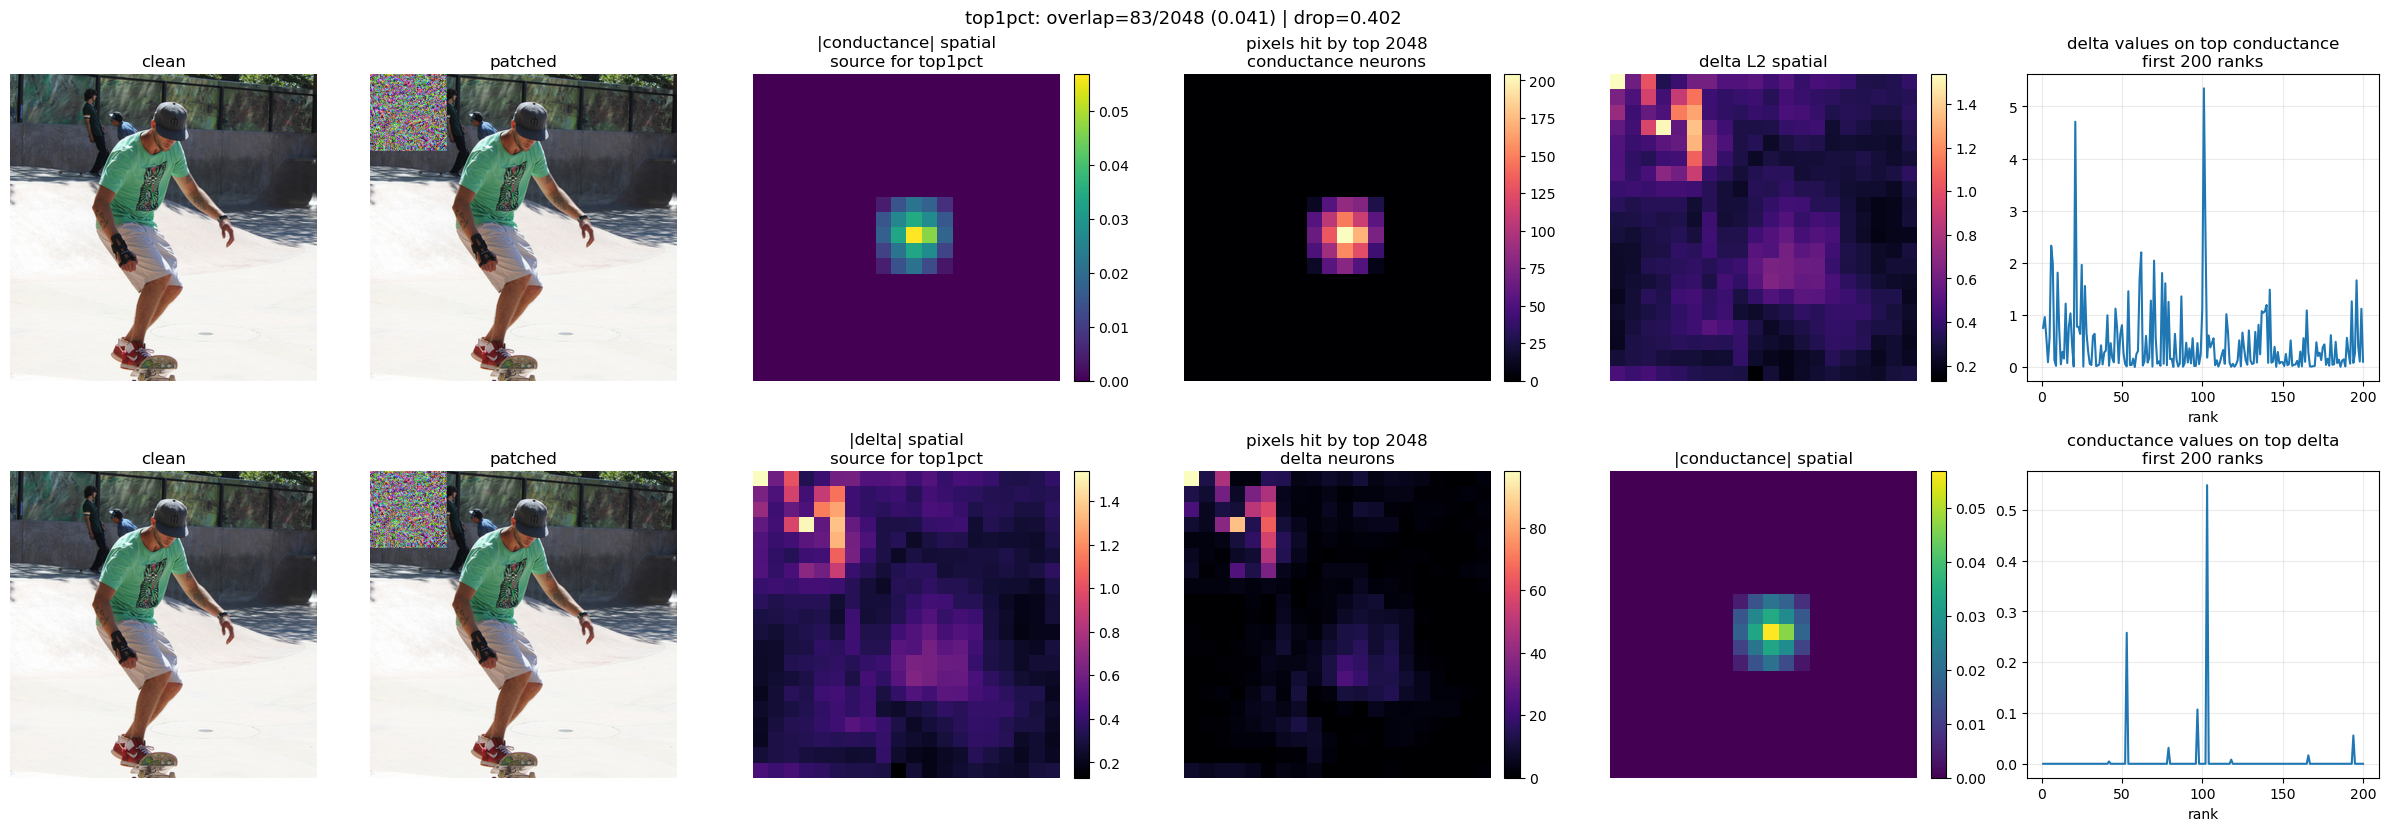

top10pct


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top10pct by |conductance|,1,52211,130,10,11,0.750977,0.750977,-1.618164,1.618164
1,top10pct by |conductance|,2,85411,213,10,11,0.957031,0.957031,1.199219,1.199219
2,top10pct by |conductance|,3,52212,130,10,12,0.560059,0.560059,1.106445,1.106445
3,top10pct by |conductance|,4,32570,81,8,10,-0.091736,0.091736,-1.091797,1.091797
4,top10pct by |conductance|,5,85391,213,9,11,0.566895,0.566895,1.009766,1.009766
...,...,...,...,...,...,...,...,...,...,...
195,top10pct by |conductance|,196,31811,79,10,11,-1.662109,1.662109,0.189819,0.189819
196,top10pct by |conductance|,197,59009,147,10,9,-0.402100,0.402100,-0.189087,0.189087
197,top10pct by |conductance|,198,95811,239,10,11,-0.103943,0.103943,-0.188843,0.188843
198,top10pct by |conductance|,199,85430,213,11,10,1.117188,1.117188,0.186523,0.186523


,source,rank,flat_idx,channel,y,x,delta,abs_delta,conductance,abs_conductance
0,top10pct by |delta|,1,16065,40,3,5,-8.195312,8.195312,0.0,0.0
1,top10pct by |delta|,2,202444,506,2,4,8.078125,8.078125,0.0,0.0
2,top10pct by |delta|,3,67200,168,0,0,7.773438,7.773438,0.0,0.0
3,top10pct by |delta|,4,16000,40,0,0,7.609375,7.609375,0.0,0.0
4,top10pct by |delta|,5,71644,179,2,4,7.324219,7.324219,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
195,top10pct by |delta|,196,123725,309,6,5,-3.839844,3.839844,0.0,0.0
196,top10pct by |delta|,197,53263,133,3,3,3.824219,3.824219,0.0,0.0
197,top10pct by |delta|,198,31325,78,6,5,-3.822266,3.822266,0.0,0.0
198,top10pct by |delta|,199,199786,499,9,6,3.798828,3.798828,0.0,0.0


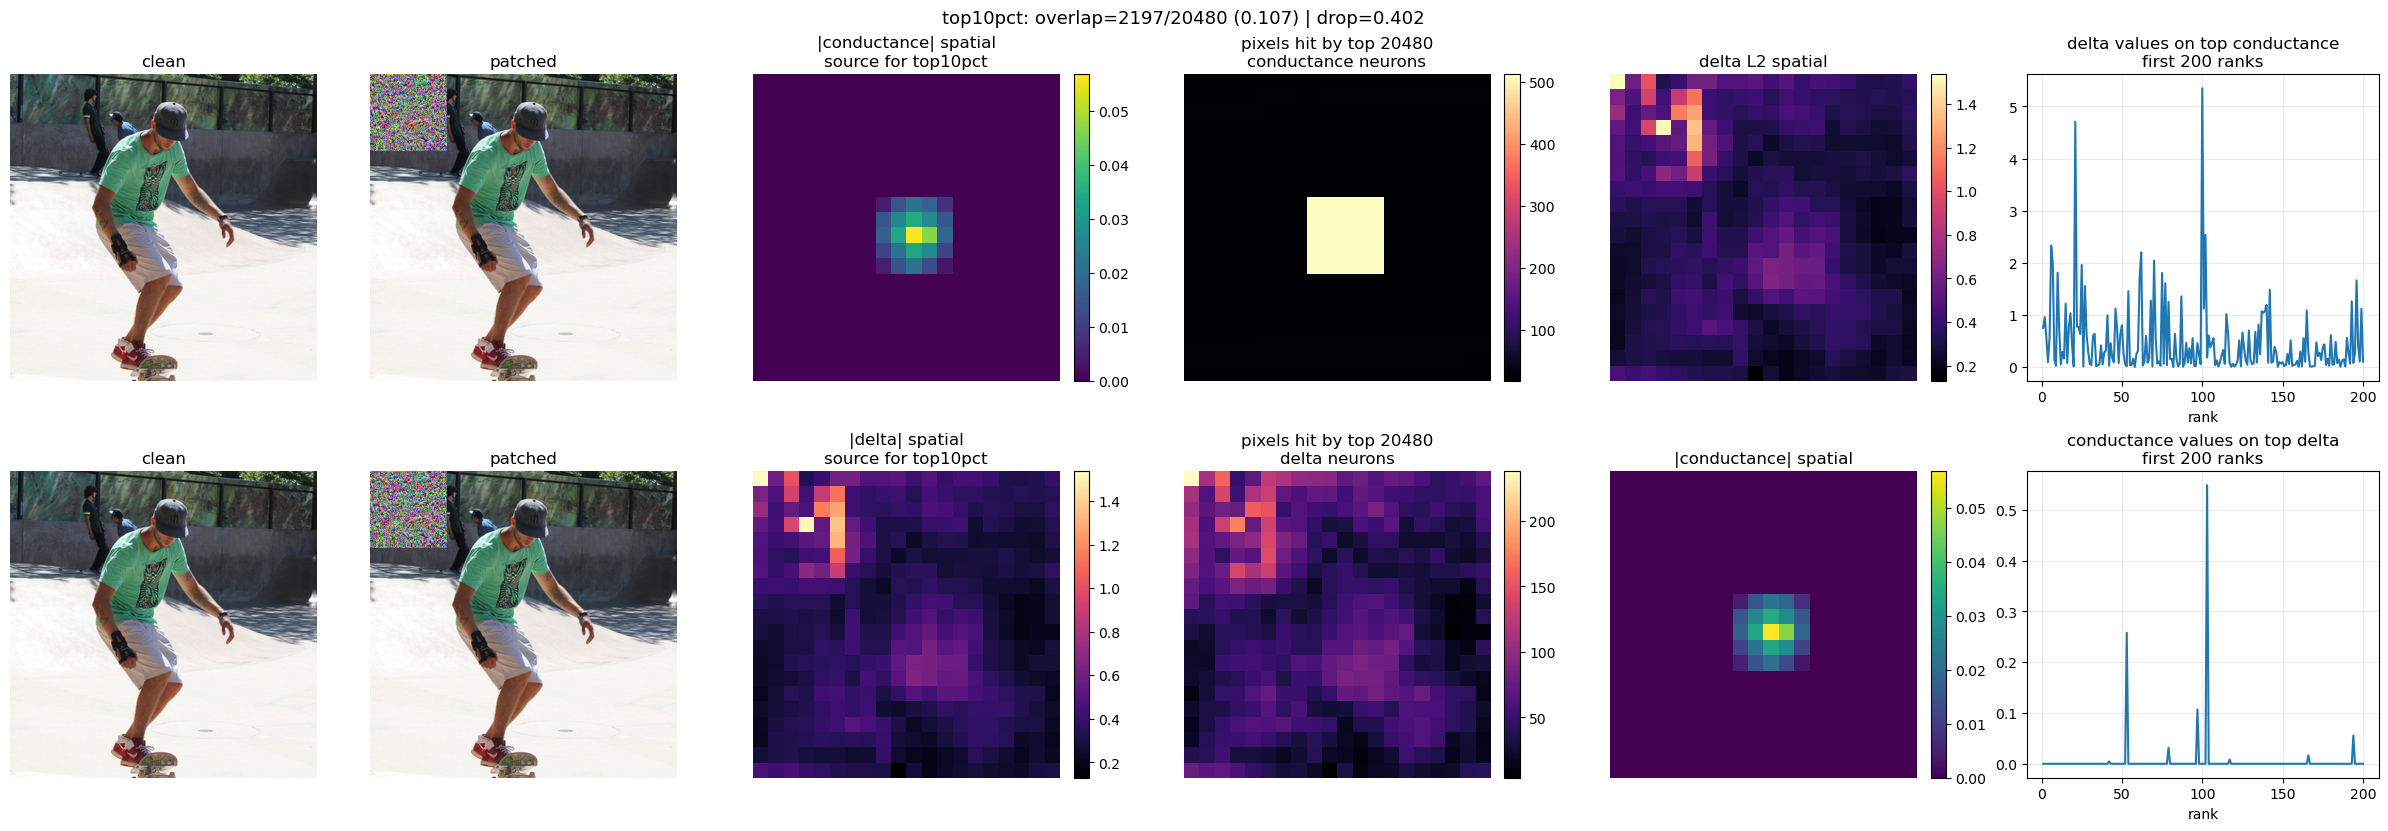

In [4]:
example_row_index = 0
example_row = raw_df.iloc[example_row_index]
clean_lb, patched_lb = clean_patched_for_path(example_row["path"])

top_sets = raw_maps.top_neuron_sets(
    example_row["delta_chw"],
    example_row["conductance_chw"],
    fractions=(0.01, 0.10),
    top_ns=(200,),
)

summary_rows = []
for subset_key, entry in top_sets.items():
    idx_c = entry["by_conductance"]
    idx_d = entry["by_delta"]
    c_set = set(int(v) for v in idx_c)
    d_set = set(int(v) for v in idx_d)
    summary_rows.append({
        "subset": subset_key,
        "k": int(entry["k"]),
        "overlap": len(c_set & d_set),
        "overlap_frac": len(c_set & d_set) / max(1, int(entry["k"])),
        "mean_abs_delta_on_top_conductance": float(abs(example_row["delta_chw"].reshape(-1)[idx_c]).mean()),
        "mean_abs_conductance_on_top_delta": float(abs(example_row["conductance_chw"].reshape(-1)[idx_d]).mean()),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

for subset_key, entry in top_sets.items():
    print(subset_key)
    top_conductance_table = raw_maps.top_set_value_table(
        example_row["delta_chw"],
        example_row["conductance_chw"],
        entry["by_conductance"],
        source=f"{subset_key} by |conductance|",
        max_rows=200,
    )
    top_delta_table = raw_maps.top_set_value_table(
        example_row["delta_chw"],
        example_row["conductance_chw"],
        entry["by_delta"],
        source=f"{subset_key} by |delta|",
        max_rows=200,
    )
    display(top_conductance_table)
    display(top_delta_table)
    fig = raw_maps.plot_top_conductance_delta_cross(
        example_row,
        subset_key=subset_key,
        clean_img=clean_lb,
        patched_img=patched_lb,
    )
    plt.show()


## Сырые значения: delta vs conductance

delta values: n=4,915,200, min=-16.3906, max=11.5234
conductance values: n=4,915,200, min=-129.25, max=157.375


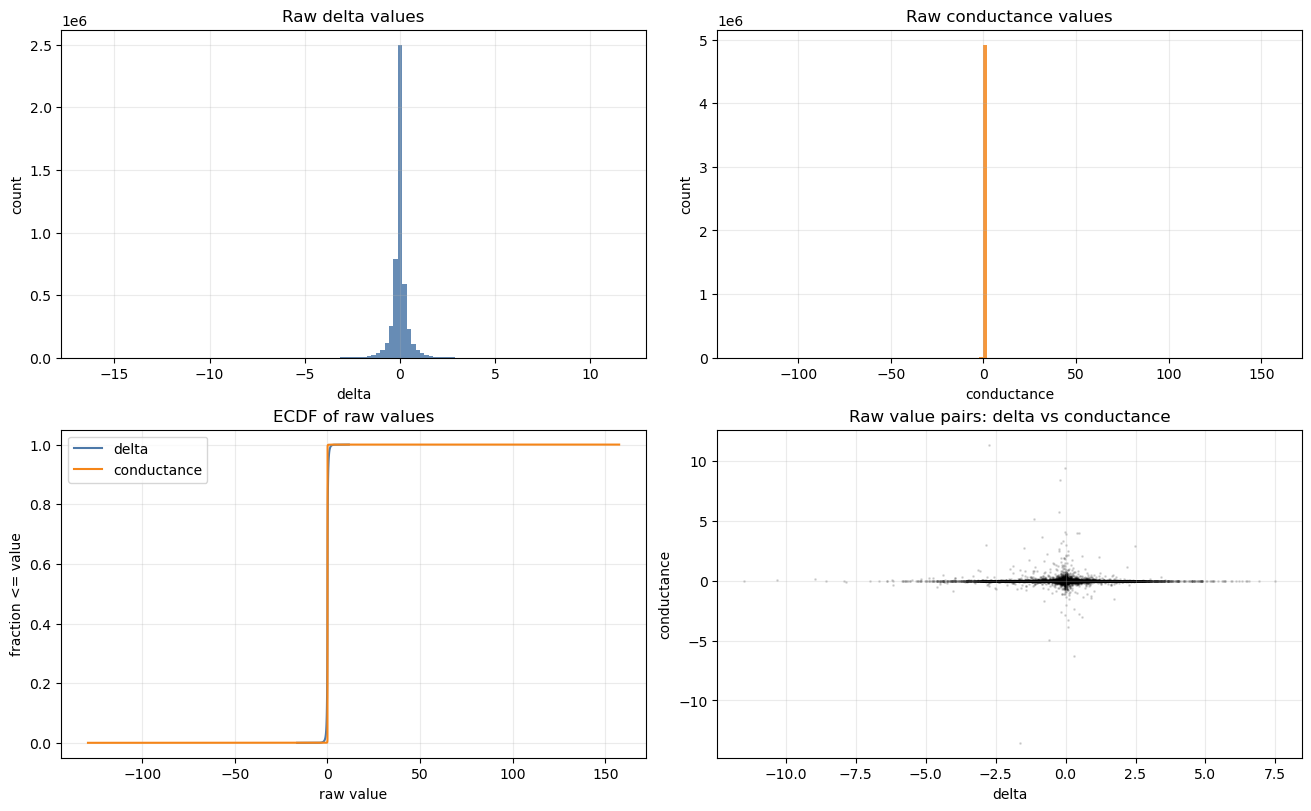

In [5]:
import numpy as np

delta_values = np.concatenate([row.reshape(-1).astype("float32", copy=False) for row in raw_df["delta_chw"]])
conductance_values = np.concatenate([row.reshape(-1).astype("float32", copy=False) for row in raw_df["conductance_chw"]])

print(f"delta values: n={delta_values.size:,}, min={delta_values.min():.6g}, max={delta_values.max():.6g}")
print(f"conductance values: n={conductance_values.size:,}, min={conductance_values.min():.6g}, max={conductance_values.max():.6g}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

axes[0, 0].hist(delta_values[np.isfinite(delta_values)], bins=120, color="#4C78A8", alpha=0.85)
axes[0, 0].set_title("Raw delta values")
axes[0, 0].set_xlabel("delta")
axes[0, 0].set_ylabel("count")
axes[0, 0].grid(alpha=0.25)

axes[0, 1].hist(conductance_values[np.isfinite(conductance_values)], bins=120, color="#F58518", alpha=0.85)
axes[0, 1].set_title("Raw conductance values")
axes[0, 1].set_xlabel("conductance")
axes[0, 1].set_ylabel("count")
axes[0, 1].grid(alpha=0.25)

for values, label, color in [
    (delta_values, "delta", "#4C78A8"),
    (conductance_values, "conductance", "#F58518"),
]:
    finite = np.sort(values[np.isfinite(values)].astype("float64"))
    y = np.linspace(0.0, 1.0, finite.size)
    axes[1, 0].plot(finite, y, label=label, color=color)
axes[1, 0].set_title("ECDF of raw values")
axes[1, 0].set_xlabel("raw value")
axes[1, 0].set_ylabel("fraction <= value")
axes[1, 0].grid(alpha=0.25)
axes[1, 0].legend()

sample_n = min(200_000, delta_values.size, conductance_values.size)
sample_idx = np.linspace(0, min(delta_values.size, conductance_values.size) - 1, sample_n).astype(int)
axes[1, 1].scatter(delta_values[sample_idx], conductance_values[sample_idx], s=1, alpha=0.12, color="black")
axes[1, 1].set_title("Raw value pairs: delta vs conductance")
axes[1, 1].set_xlabel("delta")
axes[1, 1].set_ylabel("conductance")
axes[1, 1].grid(alpha=0.25)

plt.show()

## Общая статистика raw values

In [6]:
stats_df = pd.DataFrame([
    {"tensor": "delta", **raw_maps.raw_tensor_stats(delta_values)},
    {"tensor": "conductance", **raw_maps.raw_tensor_stats(conductance_values)},
])
display(stats_df)

per_image_cols = [
    "delta_min", "delta_p01", "delta_p50", "delta_p99", "delta_max", "delta_mean", "delta_std", "delta_mean_abs", "delta_l2_rms",
    "conductance_min", "conductance_p01", "conductance_p50", "conductance_p99", "conductance_max",
    "conductance_mean", "conductance_std", "conductance_mean_abs", "conductance_l2_rms",
]
display(raw_df[per_image_cols].describe().T)

,tensor,min,p01,p50,p99,max,mean,std,mean_abs,l2_rms
0,delta,-16.390625,-1.491211,-0.006607,1.432617,11.523438,-0.010688,0.469947,0.249944,0.470069
1,conductance,-129.250000,-0.019196,0.000000,0.027710,157.375000,0.000448,0.167603,0.003623,0.167604


,count,mean,std,min,25%,50%,75%,max
delta_min,24.0,-9.249674,3.220915,-16.390625,-9.830078,-8.746094,-6.985352,-4.675781
delta_p01,24.0,-1.459741,0.388593,-2.183594,-1.734141,-1.316411,-1.171631,-0.892090
delta_p50,24.0,-0.007903,0.007131,-0.025101,-0.012501,-0.006961,-0.001065,0.001252
delta_p99,24.0,1.411095,0.174839,1.020508,1.318359,1.398447,1.550295,1.720703
delta_max,24.0,7.883138,0.868511,6.992188,7.488281,7.685547,7.889648,11.523438
delta_mean,24.0,-0.010688,0.010438,-0.030088,-0.015695,-0.011148,-0.006187,0.010715
delta_std,24.0,0.463749,0.077007,0.331176,0.416233,0.443660,0.514850,0.610143
delta_mean_abs,24.0,0.249944,0.042345,0.172934,0.227297,0.244132,0.266372,0.336416
delta_l2_rms,24.0,0.463985,0.077003,0.331352,0.416393,0.443863,0.514951,0.610279
conductance_min,24.0,-21.428589,35.383201,-129.250000,-11.720703,-4.380859,-1.607422,0.000000
